In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/SC4001_Group_Assignment_2')

Mounted at /content/drive


In [2]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from sklearn.metrics import accuracy_score, f1_score
from torch.optim.lr_scheduler import OneCycleLR
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder

from common_utils import *

In [5]:
dataset = load_dataset("csv", data_files="/content/drive/MyDrive/SC4001_Group_Assignment_2/dataset/wassa_combined_data.csv")
dataset = dataset.rename_column('tweet', 'text')
dataset_dict = create_train_validation_test(dataset['train'])

embedding_matrix = np.load("/content/drive/MyDrive/SC4001_Group_Assignment_2/dataset/result/embedding_matrix.npy")

with open("/content/drive/MyDrive/SC4001_Group_Assignment_2/dataset/result/word2idx.json", "r", encoding="utf-8") as f:
    word2idx = json.load(f)

Generating train split: 0 examples [00:00, ? examples/s]

Train size: 5592
Validation size: 799
Test size: 711


In [6]:
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(dataset_dict['train']['sentiment'])
val_labels = label_encoder.transform(dataset_dict['validation']['sentiment'])
test_labels = label_encoder.transform(dataset_dict['test']['sentiment'])
num_classes = len(label_encoder.classes_)
print(f"Number of sentiment classes: {num_classes}")
print(f"Emotion classes: {label_encoder.classes_}")

crowd_labels_dict = {
    'train': train_labels,
    'validation': val_labels,
    'test': test_labels
}

Number of sentiment classes: 4
Emotion classes: ['anger' 'fear' 'joy' 'sadness']


In [7]:
dataloaders_dict = create_dataloaders(dataset_dict, crowd_labels_dict, word2idx)

Created DataLoaders with 175 training batches, 25 validation batches, and 23 test batches.


In [48]:
# Attention Module
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.hidden_dim = hidden_dim
        self.main = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(True),
            nn.Linear(64, 1)
        )

    def forward(self, lstm_output):
        attn_weights = self.main(lstm_output)
        attn_weights = torch.softmax(attn_weights.squeeze(2), dim=1)
        return attn_weights

# BiLSTM without Attention Model
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, pretrained_embeddings, drop_prob=0.5):
        super(BiLSTM, self).__init__()

        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=drop_prob if n_layers > 1 else 0, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(drop_prob)

        self.fc = nn.Linear(hidden_dim * 2, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)

        lstm_out = lstm_out[:, -1, :]
        out = self.dropout(lstm_out)
        out = self.fc(out)
        soft_out = self.softmax(out)

        return soft_out


# BiLSTM with Attention Model
class BiLSTMWithAttention(nn.Module):
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, pretrained_embeddings, drop_prob=0.5):
        super(BiLSTMWithAttention, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=drop_prob if n_layers > 1 else 0, batch_first=True, bidirectional=True)
        self.attention = Attention(hidden_dim * 2)  # since it's BiLSTM, hidden_dim * 2
        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(hidden_dim * 2, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        attn_weights = self.attention(lstm_out)
        attn_applied = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)  # weighted sum of lstm output
        out = self.dropout(attn_applied)
        out = self.fc(out)
        soft_out = self.softmax(out)
        return soft_out

In [58]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs, filepath):
    since = time.time()
    best_model_wts = model.state_dict()
    best_val_f1 = 0.0

    patience = 5
    no_improve_epochs = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        scheduler.step()

                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} F1: {epoch_f1:.4f}')

            tolerance = 0.010

            if phase == 'validation':
                if epoch_f1 > best_val_f1 + tolerance:
                    best_val_f1 = epoch_f1
                    best_model_wts = model.state_dict().copy()
                    no_improve_epochs = 0

                    # Save the model with dynamic filepath
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'val_f1': epoch_f1,
                    }, filepath)
                else:
                    no_improve_epochs += 1
                    print(f'No improvement for {no_improve_epochs} epochs')

                if no_improve_epochs >= patience:
                    print(f'Early stopping triggered after {epoch+1} epochs')
                    time_elapsed = time.time() - since
                    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
                    print(f'Best val F1: {best_val_f1:.4f}')
                    model.load_state_dict(best_model_wts)
                    return model

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val F1: {best_val_f1:.4f}')

    model.load_state_dict(best_model_wts)
    return model


def evaluate_model(model, test_dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = accuracy_score(all_labels, all_preds)
    test_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f'Test Accuracy: {test_acc:.4f}')
    print(f'Test F1 Score: {test_f1:.4f}')

    return test_acc, test_f1


## BiLSTM model (without attention)

In [59]:
# convert the embedding matrix to a torch tensor
embedding_matrix_tensor = torch.FloatTensor(embedding_matrix)

model = BiLSTM(vocab_size=len(word2idx),
                    output_size=len(label_encoder.classes_),  # num_classes
                    embedding_dim=100,
                    hidden_dim=256,
                    n_layers=2,
                    pretrained_embeddings=embedding_matrix_tensor)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

total_steps = 100 * len(dataloaders_dict['train'])
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.001, total_steps=total_steps, pct_start=0.1, anneal_strategy='cos')


Using device: cuda


In [60]:
trained_model_bilstm = train_model(model,
                                  dataloaders_dict,
                                  criterion,
                                  optimizer,
                                  scheduler,
                                  num_epochs=100,
                                  filepath="/content/drive/MyDrive/SC4001_Group_Assignment_2/dataset/models/best_bilstm_model.pt"
)

test_acc, test_f1 = evaluate_model(trained_model_bilstm, dataloaders_dict['test'])

Epoch 1/100
----------
train Loss: 1.3799 Acc: 0.3074 F1: 0.1896
validation Loss: 1.3775 Acc: 0.3116 F1: 0.1481

Epoch 2/100
----------
train Loss: 1.3762 Acc: 0.3160 F1: 0.1517
validation Loss: 1.3779 Acc: 0.3116 F1: 0.1481
No improvement for 1 epochs

Epoch 3/100
----------
train Loss: 1.3757 Acc: 0.3160 F1: 0.1517
validation Loss: 1.3789 Acc: 0.3116 F1: 0.1481
No improvement for 2 epochs

Epoch 4/100
----------
train Loss: 1.3760 Acc: 0.3160 F1: 0.1517
validation Loss: 1.3787 Acc: 0.3116 F1: 0.1481
No improvement for 3 epochs

Epoch 5/100
----------
train Loss: 1.3761 Acc: 0.3160 F1: 0.1517
validation Loss: 1.3772 Acc: 0.3116 F1: 0.1481
No improvement for 4 epochs

Epoch 6/100
----------
train Loss: 1.3759 Acc: 0.3160 F1: 0.1517
validation Loss: 1.3771 Acc: 0.3116 F1: 0.1481
No improvement for 5 epochs
Early stopping triggered after 6 epochs
Training complete in 0m 27s
Best val F1: 0.1481
Test Accuracy: 0.3319
Test F1 Score: 0.1654


## BiLSTM model (with attention)

In [61]:
# convert the embedding matrix to a torch tensor
embedding_matrix_tensor = torch.FloatTensor(embedding_matrix)

model = BiLSTMWithAttention(len(word2idx), len(label_encoder.classes_), 100, 256, 2, embedding_matrix_tensor)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

total_steps = 100 * len(dataloaders_dict['train'])
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.001, total_steps=total_steps, pct_start=0.1, anneal_strategy='cos')


Using device: cuda


In [62]:
trained_model_bilstm_att = train_model(
                                    model,
                                    dataloaders_dict,
                                    criterion,
                                    optimizer,
                                    scheduler,
                                    num_epochs=100,
                                    filepath="/content/drive/MyDrive/SC4001_Group_Assignment_2/dataset/models/best_bilstm_with_attention_model.pt"
)

test_acc, test_f1 = evaluate_model(trained_model_bilstm_att , dataloaders_dict['test'])


Epoch 1/100
----------
train Loss: 1.3775 Acc: 0.3029 F1: 0.1833
validation Loss: 1.3781 Acc: 0.3116 F1: 0.1481

Epoch 2/100
----------
train Loss: 1.3687 Acc: 0.3160 F1: 0.1531
validation Loss: 1.3855 Acc: 0.3116 F1: 0.1481
No improvement for 1 epochs

Epoch 3/100
----------
train Loss: 1.2945 Acc: 0.3864 F1: 0.3260
validation Loss: 1.2433 Acc: 0.4118 F1: 0.3878

Epoch 4/100
----------
train Loss: 0.9988 Acc: 0.5848 F1: 0.5776
validation Loss: 0.7936 Acc: 0.6733 F1: 0.6614

Epoch 5/100
----------
train Loss: 0.5562 Acc: 0.7902 F1: 0.7899
validation Loss: 0.4375 Acc: 0.8411 F1: 0.8416

Epoch 6/100
----------
train Loss: 0.3384 Acc: 0.8784 F1: 0.8786
validation Loss: 0.3616 Acc: 0.8686 F1: 0.8680

Epoch 7/100
----------
train Loss: 0.2440 Acc: 0.9154 F1: 0.9155
validation Loss: 0.3642 Acc: 0.8661 F1: 0.8665
No improvement for 1 epochs

Epoch 8/100
----------
train Loss: 0.1818 Acc: 0.9367 F1: 0.9367
validation Loss: 0.3855 Acc: 0.8686 F1: 0.8685
No improvement for 2 epochs

Epoch 9/100


In [63]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Confusion Matrix (Normalized)')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def plot_roc_auc(model, dataloader, num_classes):
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.exp(outputs)  # get probabilities using softmax
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # ROC Curve & AUC Calculation
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels == i, all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    plt.figure()
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()

# update the evaluate function to include confusion matrix and ROC plot
def evaluate_model_with_metrics(model, test_dataloader, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = accuracy_score(all_labels, all_preds)
    test_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f'Test Accuracy: {test_acc:.4f}')
    print(f'Test F1 Score: {test_f1:.4f}')

    plot_confusion_matrix(all_labels, all_preds, num_classes)
    plot_roc_auc(model, test_dataloader, num_classes)

    return test_acc, test_f1

Test Accuracy: 0.3319
Test F1 Score: 0.1654


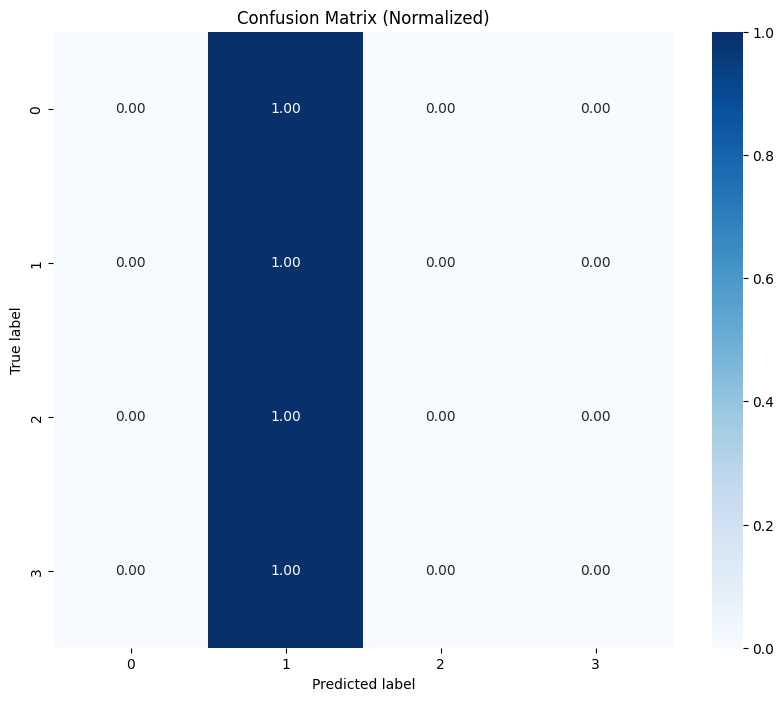

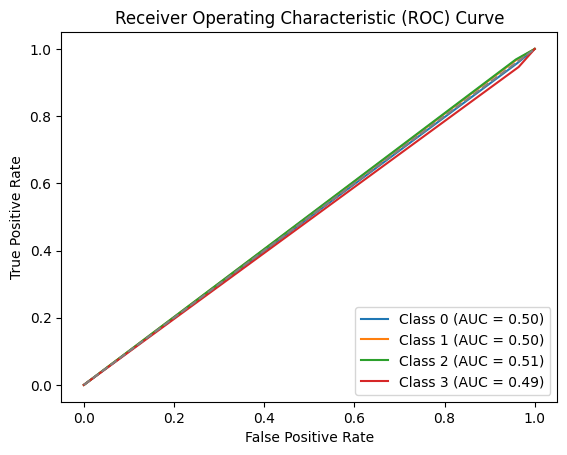

In [64]:
num_classes = len(label_encoder.classes_)
test_acc, test_f1 = evaluate_model_with_metrics(trained_model_bilstm, dataloaders_dict['test'], num_classes)

Test Accuracy: 0.8650
Test F1 Score: 0.8657


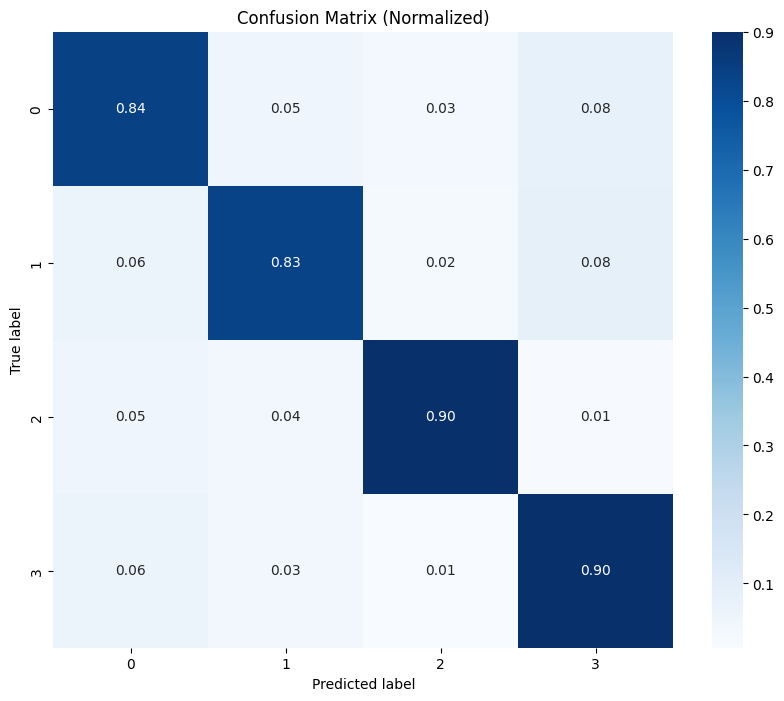

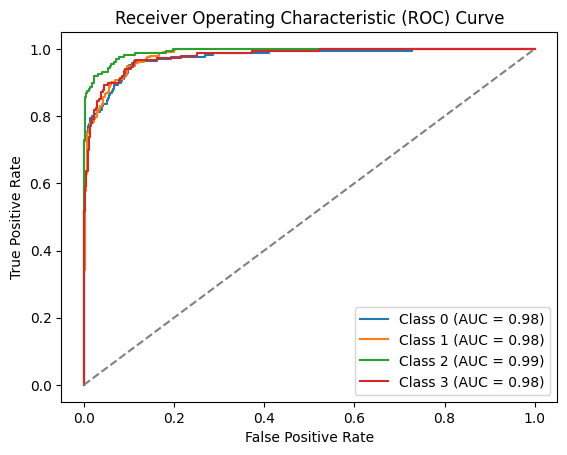

In [65]:
test_acc, test_f1 = evaluate_model_with_metrics(trained_model_bilstm_att, dataloaders_dict['test'], num_classes)